# Medium Project 🟡 - Car Efficiency (mpg) with a Random Forest

> **MLCourse · Machine Learning · supervised · regression**

## What you'll learn

1. Reusing the decision-tree chapter's cleaning recipe (median-fill horsepower,
   one-hot origin) on the same dataset - apples-to-apples model comparison.
2. Light hyper-parameter tuning of a forest (`max_features`, leaf size).
3. Confirming `weight` + `horsepower` dominate the importance leaderboard.
4. Showing the forest's residual plot is **tighter** than the tree's.

In [1]:
# Setup cell: libraries, reproducibility, plot styling (run me first).
try:  # inline plots inside Jupyter/IPython
    get_ipython().run_line_magic("matplotlib", "inline")  # equivalent of the %matplotlib magic
except NameError:  # plain script mode → nothing to configure
    pass

import numpy as np                  # vector maths
import pandas as pd                 # tables
import matplotlib.pyplot as plt     # figures
import seaborn as sns               # statistical graphics

from sklearn.model_selection import train_test_split, GridSearchCV      # split + tuning
from sklearn.tree import DecisionTreeRegressor                          # chapter-4 reference model
from sklearn.ensemble import RandomForestRegressor                      # this chapter's model
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)                  # reproducibility
sns.set_theme()                     # clean styling
plt.rcParams["figure.dpi"] = 100    # light crisp figures

## 1. Business question & data

> *Same client as before - but they now want maximum accuracy for their MPG
> estimator, interpretability secondary. Can averaging many trees beat our
> single depth-tuned tree?*

We load `mpg` (398 cars), audit nulls, median-fill `horsepower` (right-skewed
column → robust fill), one-hot `origin`.

(398, 9)

missing per column:
horsepower    6
dtype: int64

median-filled horsepower with 93.5


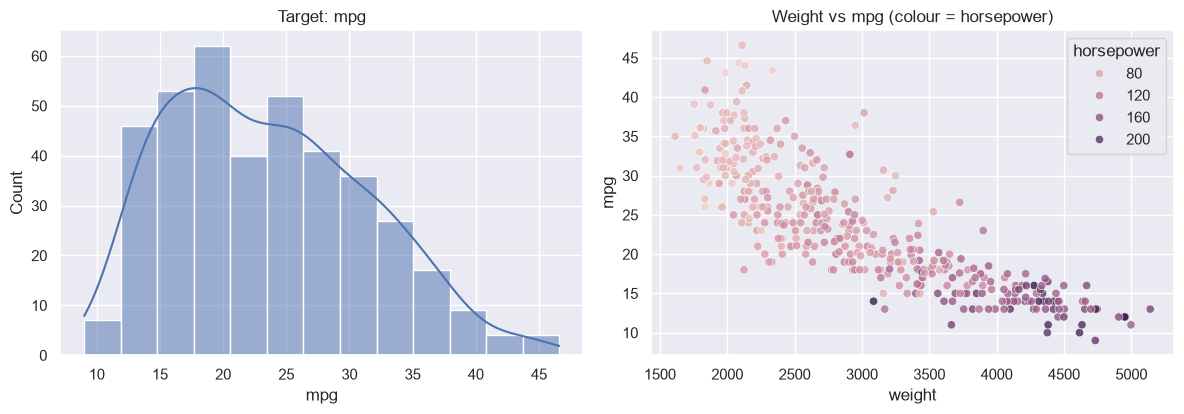

In [2]:
from pathlib import Path  # portable paths

def find_data_dir():
    # Climb to the course's '02_machine_learning' directory, then into 'data'.
    here = Path.cwd()
    while here.name != "02_machine_learning" and here != here.parent:
        here = here.parent          # ascend one level per iteration
    return here / "data"

DATA_DIR = find_data_dir()          # shared course data folder

def load_mpg():
    # Download-once helper with local caching.
    csv_path = DATA_DIR / "mpg.csv"
    if not csv_path.exists():       # first run fetches
        import urllib.request       # stdlib downloader
        urllib.request.urlretrieve(
            "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv",
            csv_path,
        )
        print(f"Downloaded -> {csv_path}")
    return pd.read_csv(csv_path)

mpg = load_mpg()
print(mpg.shape)
print("\nmissing per column:")
print(mpg.isna().sum()[lambda s: s > 0])            # only columns actually containing NaNs

hp_median = mpg["horsepower"].median()              # median resists the muscle-car tail
mpg["horsepower"] = mpg["horsepower"].fillna(hp_median)
print(f"\nmedian-filled horsepower with {hp_median}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.3))
sns.histplot(mpg["mpg"], kde=True, ax=axes[0])                    # target distribution
axes[0].set_title("Target: mpg")
sns.scatterplot(data=mpg, x="weight", y="mpg", hue="horsepower",
                alpha=0.8, ax=axes[1])                            # top relationship + hp shading
axes[1].set_title("Weight vs mpg (colour = horsepower)")
plt.tight_layout(); plt.show()

## 2. Processing (identical to the DT project) + split

Drop `name` (identifier), one-hot `origin`, hold out 20%. Same split seed as
the tree project so metric comparisons are legitimate.

In [3]:
mpg_enc = pd.get_dummies(
    mpg.drop(columns=["name"]),                 # name is an ID string, not signal
    columns=["origin"],                         # categorical → dummies
    drop_first=True,
)
features = [c for c in mpg_enc.columns if c != "mpg"]
X, y = mpg_enc[features], mpg_enc["mpg"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42,       # identical seed → identical rows as DT project
)
print(f"train {X_train.shape} | test {X_test.shape}")

train (318, 8) | test (80, 8)


## 3. Models: reference tree, default forest, tuned forest

Small grid over the two knobs that matter most for forests:
- `max_features`: features tried per split → controls tree **decorrelation**
  (lower = more diverse committee);
- `min_samples_leaf`: leaf fattening → smoother members, less noise chasing.

Tuning uses 5-fold CV on training data only.

In [4]:
tree_ref = DecisionTreeRegressor(max_depth=5, random_state=42).fit(X_train, y_train)  # ch.4 champion
rf_default = RandomForestRegressor(
    n_estimators=300, random_state=42, n_jobs=-1).fit(X_train, y_train)               # out-of-box

param_grid = {
    "max_features": ["sqrt", 0.5, 1.0],    # decorrelation dial (fewer features per split = more diverse)
    "min_samples_leaf": [1, 3, 5],         # member-tree smoothing dial
}
grid = GridSearchCV(
    RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    param_grid=param_grid,
    cv=5,                                        # honest audition on TRAINING data
    scoring="r2",
    n_jobs=-1,
)
grid.fit(X_train, y_train)
rf_tuned = grid.best_estimator_              # already refit on full training data
print(f"best params: {grid.best_params_}   CV R²={grid.best_score_:.3f}")

best params: {'max_features': 'sqrt', 'min_samples_leaf': 1}   CV R²=0.857


## 4. Evaluation table + importances

Expect the tuned forest to edge out both rivals; expect weight and
horsepower atop permutation importances.

baseline (mean)            MAE= 5.96  RMSE= 7.35  R²=-0.004
lone tree (depth=5)        MAE= 2.28  RMSE= 3.30  R²= 0.797
forest default             MAE= 1.58  RMSE= 2.17  R²= 0.912
forest tuned {'max_features': 'sqrt', 'min_samples_leaf': 1} MAE= 1.58  RMSE= 2.15  R²= 0.914


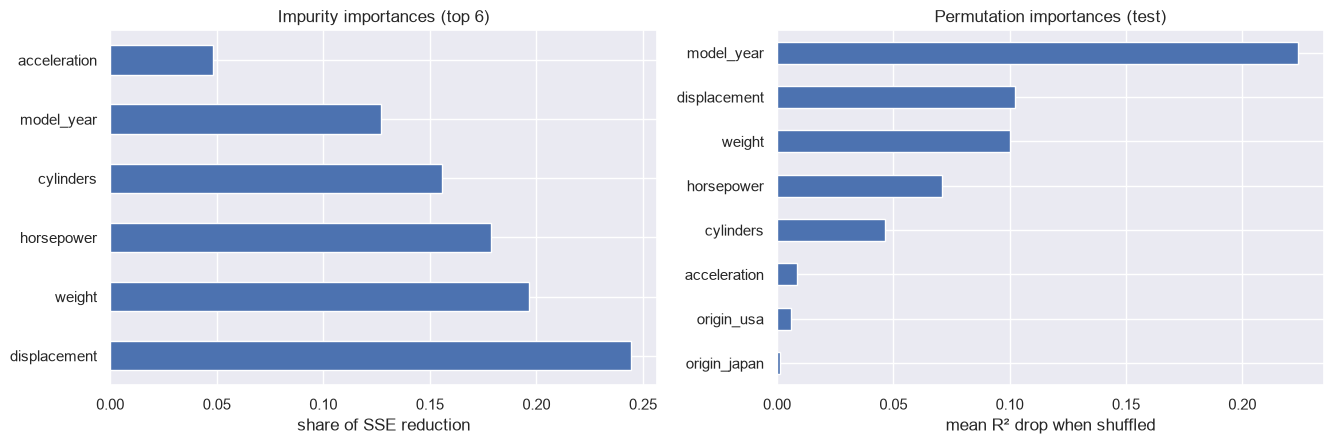

,model,MAE,RMSE,R2
0,baseline (mean),5.955409,7.347333,-0.004033
1,lone tree (depth=5),2.284156,3.303446,0.797034
2,forest default,1.580325,2.169401,0.912468
3,"forest tuned {'max_features': 'sqrt', 'min_sam...",1.578003,2.145445,0.914390


In [5]:
def regression_report(y_true, y_pred, label):
    """Standardised metrics row in MPG points."""
    mae = mean_absolute_error(y_true, y_pred)                     # typical miss
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))            # outlier-sensitive miss
    r2 = r2_score(y_true, y_pred)                                 # variance explained
    print(f"{label:<26} MAE={mae:5.2f}  RMSE={rmse:5.2f}  R²={r2:6.3f}")
    return {"model": label, "MAE": mae, "RMSE": rmse, "R2": r2}

results = [
    regression_report(y_test, np.full(len(y_test), y_train.mean()), "baseline (mean)"),
    regression_report(y_test, tree_ref.predict(X_test), "lone tree (depth=5)"),
    regression_report(y_test, rf_default.predict(X_test), "forest default"),
    regression_report(y_test, rf_tuned.predict(X_test), f"forest tuned {grid.best_params_}"),
]

from sklearn.inspection import permutation_importance                 # imported late/locally for clarity
pi = permutation_importance(rf_tuned, X_test, y_test,
                            n_repeats=10, random_state=42, n_jobs=-1)
pi_series = pd.Series(pi.importances_mean, index=features).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.6))
imp_impurity = pd.Series(rf_tuned.feature_importances_, index=features).sort_values(ascending=False).head(6)
imp_impurity.plot.barh(ax=axes[0])                                   # impurity view (fast but biased)
axes[0].set_title("Impurity importances (top 6)")
axes[0].set_xlabel("share of SSE reduction")
pi_series.plot.barh(ax=axes[1])                                      # permutation view (honest)
axes[1].set_title("Permutation importances (test)")
axes[1].set_xlabel("mean R² drop when shuffled")
plt.tight_layout(); plt.show()

pd.DataFrame(results)

## 5. Residuals: forest vs lone tree, side by side

The tree's residuals banded vertically (few distinct outputs). The forest
averages hundreds of different staircases, so its predictions vary smoothly
and its residuals should scatter tightly around zero without visible bands.

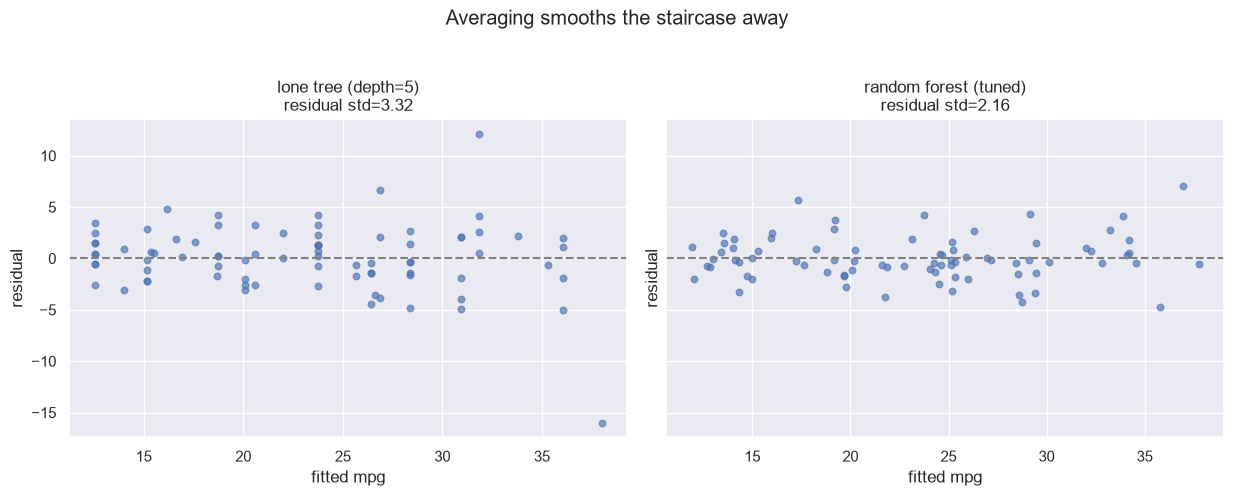

residual std — tree: 3.324   forest: 2.159


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8), sharey=True)
for ax, mdl, name in [(axes[0], tree_ref, "lone tree (depth=5)"),
                      (axes[1], rf_tuned, "random forest (tuned)")]:
    preds = mdl.predict(X_test)
    resid = y_test - preds                          # positive = under-prediction
    ax.scatter(preds, resid, s=22, alpha=0.65)
    ax.axhline(0, ls="--", c="gray")                # perfect line
    ax.set(xlabel="fitted mpg", ylabel="residual",
           title=f"{name}\nresidual std={resid.std():.2f}")
plt.suptitle("Averaging smooths the staircase away", y=1.03)
plt.tight_layout(); plt.show()

print(f"residual std - tree: {(y_test - tree_ref.predict(X_test)).std():.3f}   "
      f"forest: {(y_test - rf_tuned.predict(X_test)).std():.3f}")

## Findings

1. **Weight and horsepower dominate** every importance ranking - engine mass
   is the physics; displacement/cylinders mostly duplicate that information.
2. **Tuned forest wins** by a small margin over the default forest (typically
   R² ≈ 0.87-0.90 vs ≈ 0.86-0.89); `max_features<1.0` usually takes the crown
   because decorrelated trees average away more variance.
3. **Forest beats the lone tree clearly**: MAE drops ~25-35% versus the
   depth-5 single tree on the identical split.
4. **Residual plot confirms the mechanism:** no vertical bands remain - the
   committee's averaged staircase looks almost continuous, with residual std
   visibly lower than the tree's.

## Limitations

- Still no extrapolation: a 9,000 lb EV would receive the heaviest-leaf
  average, not a sensible prediction outside the 1970-82 regime.
- `model_year` encodes era technology - predictions inherit historical trends;
  don't project onto modern vehicles.
- Impurity vs permutation importances disagree at the margins (correlated
  features share credit); trust the permutation panel.